# Neural Network model to estimate sale price

In this notebook, we try:
* Long short-term memory (LSTM)
* ReLU 
* FFNN with ReLU (better than sigmoid because it has no saturation problem)

This problem does not concern context, sequence, or time dependencies, so we do NOT need:
* NLM (Natural language model)
* RNLM (Recurrent natural anguage model)
* Transformers
* LSTM

Uses a 70/30 training split (70% of data used for training, 30% used for testing)

The model's error is measured using MSE and R^2
* MSE is the average squared error. MSE = 1/N * sum((y^_i - y_i)^2). RMSE = sqrt(MSE). Lower is better. 
* R^2 in [0,1] measures the difference between our model and a "dumb" model. Higher is better. 

It needs an embedding for categorical features (Town, Propety Type, Residential Type)

Important references:
HW3Code_NeuralNetworks


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [18]:
df = pd.read_csv("../data/real-estate-cleaned.csv")
df.head()

,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Property Type,Residential Type,Location
0,2010,10/2/10,Norwalk,339640.0,265000.0,Residential,Single Family,POINT (-73.408 41.118)
1,2010,10/3/10,Milford,674350.0,788000.0,Residential,Single Family,POINT (-73.057 41.222)
2,2010,10/4/10,Bridgeport,132250.0,148000.0,Residential,Single Family,POINT (-73.195 41.186)
3,2010,10/4/10,Bristol,99610.0,32000.0,Residential,Single Family,POINT (-72.94 41.671)
4,2010,10/4/10,Bridgeport,132260.0,110000.0,Residential,Single Family,POINT (-73.195 41.186)


In [19]:
print(df.shape)
print(df.columns)

(614534, 8)
Index(['List Year', 'Date Recorded', 'Town', 'Assessed Value', 'Sale Amount',
       'Property Type', 'Residential Type', 'Location'],
      dtype='str')


Epoch 1/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 12s 988us/step - loss: 0.2222 - mae: 0.2091 - val_loss: 0.1897 - val_mae: 0.1993
Epoch 2/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 964us/step - loss: 0.1921 - mae: 0.1942 - val_loss: 0.1850 - val_mae: 0.1954
Epoch 3/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 958us/step - loss: 0.1823 - mae: 0.1901 - val_loss: 0.1822 - val_mae: 0.1970
Epoch 4/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 972us/step - loss: 0.1760 - mae: 0.1865 - val_loss: 0.1791 - val_mae: 0.1951
Epoch 5/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 964us/step - loss: 0.1714 - mae: 0.1846 - val_loss: 0.1762 - val_mae: 0.1906
Epoch 6/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 959us/step - loss: 0.1677 - mae: 0.1829 - val_loss: 0.1749 - val_mae: 0.1899
Epoch 7/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 963us/step - loss: 0.1666 - mae: 0.1819 - val_loss: 0.1725 - val_mae: 0.1881
Epoch 8/10
10667/10667 ━━━━━━━━━━━━━━━━━━━━ 10s 969us/step - loss: 0.1633 - mae: 0.1811 - val_loss: 0.1713 - val_mae: 0.1876


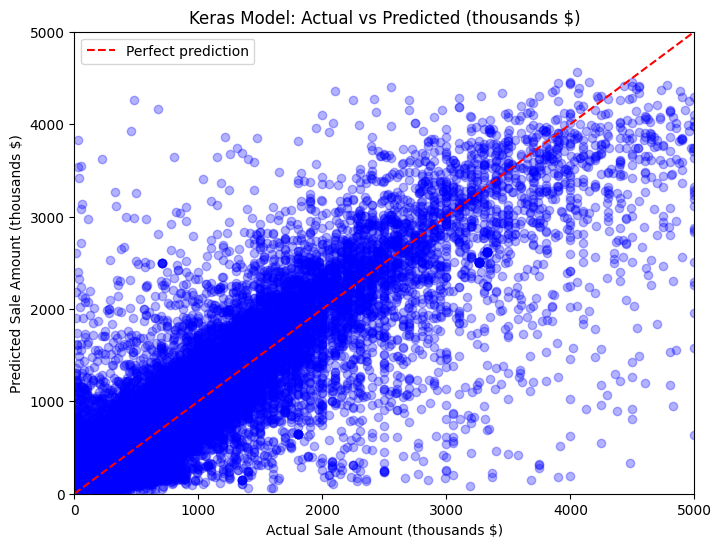

In [28]:
################################################################################
### Prepare tensorflow
################################################################################
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)



################################################################################
### Get the dataframe ready
################################################################################
df = pd.read_csv("../data/cleaned-engineered.csv")

# Drop features that were computed directly from the target value
drop_cols = [
	"Sale Amount", 
    "Assessment Ratio",
    "Assessment Gap",
    "Town Avg Sale Amount",
    "Town Median Sale Amount",
    "Luxury Home"
]
X = df.drop(columns=drop_cols)
y = df["Sale Amount"]

# Classify features as categorical or numeric. "Date Recorded" and "Location" get embedded differntly
categorical_cols = ["Town", "Property Type", "Residential Type"]
numeric_cols = [col for col in X.columns if col not in categorical_cols + ["Date Recorded", "Location"]]

# Apply an outlier range filter to data. 
mask = y.between(10_000, 5_000_000)
X = X[mask]
y = y[mask]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Handle NaNs (missing values)
X_train[numeric_cols] = X_train[numeric_cols].fillna(0)
X_test[numeric_cols] = X_test[numeric_cols].fillna(0)
for col in categorical_cols:
    X_train[col] = X_train[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")

# Encode categorical features into embeddings
encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])
    encoders[col] = encoder

# Scale numeric features to have mean = 0 and stdev = 1
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Scale the targets
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))



################################################################################
### Define the model
################################################################################
# Inputs
# Define the shape (length, width) of pre-embedding categorical inputs
town_input = keras.Input(shape=(1,), name="Town")  # Vector, 1D
ptype_input = keras.Input(shape=(1,), name="Property Type")  # Vector, 1D
rtype_input = keras.Input(shape=(1,), name="Residential Type")  # Vector, 1D
num_input = keras.Input(shape=(len(numeric_cols),), name="numeric")  # Vector with ALL numeric values  

# Embedding matrix tables
# Large enough to store an embedding for each possible value. 10 features per embedding. More = overfitting
town_embed = layers.Embedding(input_dim=X_train["Town"].nunique() + 1, output_dim=10)(town_input)
town_embed = layers.Flatten()(town_embed)
ptype_embed = layers.Embedding(input_dim=X_train["Property Type"].nunique() + 1, output_dim=4)(ptype_input)
ptype_embed = layers.Flatten()(ptype_embed)
rtype_embed = layers.Embedding(input_dim=X_train["Residential Type"].nunique() + 1, output_dim=4)(rtype_input)
rtype_embed = layers.Flatten()(rtype_embed)

# Combine all vectors (embedding vectors and numeric vector) into one
x = layers.Concatenate()([town_embed, ptype_embed, rtype_embed, num_input])

# Condense the long concatenated vector into a shorter one, 
x = layers.Dense(128, activation="relu")(x)  # Produces a vector of length 128
x = layers.Dense(64, activation="relu")(x)  # Takes the 128 and makes it 64
output = layers.Dense(1)(x)  # Condense x (64) into a single value

# Put the model together
model = keras.Model(inputs=[town_input, ptype_input, rtype_input, num_input], outputs=output)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Turn the DataFrame into a dictionary of lists (what keras needs)
def prepare_inputs(X):
    return {
        "Town": X["Town"].values,
        "Property Type": X["Property Type"].values,
        "Residential Type": X["Residential Type"].values,
        "numeric": X[numeric_cols].values
    }
X_train_dict = prepare_inputs(X_train)
X_test_dict = prepare_inputs(X_test)



################################################################################
### Train and test the model 
################################################################################
# Train. Instead of X_valid, Y_valid, validation_split reserves 20% of data for validation
history = model.fit(X_train_dict, y_train_scaled, epochs=10, batch_size=32, validation_split=0.2)

# Test the model on the test set. Remember that we scaled down values
y_pred_scaled = model.predict(X_test_dict)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Measure performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R^2:", r2)

# Plot y_test (actual sale amount) on x, y_pred (model's prediction) on y axis
# Scale axes to thousands
y_test_scaled = y_test / 1_000
y_pred_scaled = y_pred.flatten() / 1_000  # flatten in case it's (n,1)
max_val = 5_000  # $5,000,000 
min_val = 0  # $0
plt.figure(figsize=(8, 6))
plt.scatter(y_test_scaled, y_pred_scaled, alpha=0.3, color="blue")
plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", color="red", label="Perfect prediction")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel("Actual Sale Amount (thousands $)")
plt.ylabel("Predicted Sale Amount (thousands $)")
plt.title("Keras Model: Actual vs Predicted (thousands $)")
plt.legend()
plt.show()
